# Part 1: Vision Feature Extraction

How do we turn a `.png` image into numbers that a Machine Learning model can understand? We use two approaches: **Interpretable Heuristics** and **Deep Semantic Embeddings**.

### 1. Visualizing a Creative
Let's load one of our Ad creatives.

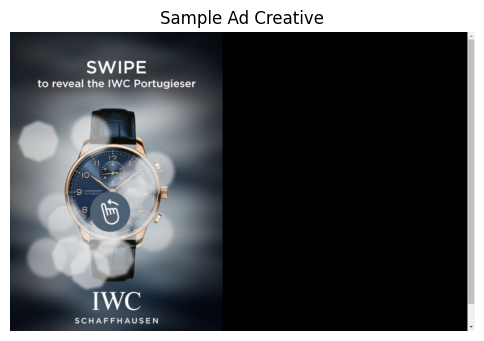

In [3]:
import matplotlib.pyplot as plt
from PIL import Image
import os

image_path = os.path.join('../data/Creative Assets_', os.listdir('../data/Creative Assets_')[0])
img = Image.open(image_path).convert('RGB')

plt.figure(figsize=(6, 8))
plt.imshow(img)
plt.axis('off')
plt.title('Sample Ad Creative')
plt.show()

### 2. Interpretable Heuristics
These are basic OpenCV/NumPy transformations that give us metrics clients easily understand (like Brightness or Colorfulness).

In [8]:
import sys
sys.path.append("..")

from src.vision.extractor import extract_handcrafted_features

# The extractor takes the raw PIL Image object directly
features = extract_handcrafted_features(img)

# Print out the extracted metrics
print(f"Brightness (0-1 scale): {features['brightness_mean']:.2f}")
print(f"Colorfulness Score: {features['colorfulness']:.2f}")
print(f"Visual Entropy (Busyness): {features['visual_entropy']:.2f}")
print(f"Aspect Ratio: {features['aspect_ratio']:.2f}")

Brightness (0-1 scale): 0.19
Colorfulness Score: 0.04
Visual Entropy (Busyness): 4.63
Aspect Ratio: 1.56


### 3. Deep Semantic Embeddings (ResNet50)
While heuristics are great, they don't understand the *content* of the image (e.g., is there a car? A person?). For this, we pass the image through a pretrained PyTorch ResNet50 model.

In [11]:
from src.vision.extractor import extract_deep_embeddings

# The function expects a list of absolute or relative string paths
# It handles the PyTorch ResNet50 initialization automatically
embedding = extract_deep_embeddings([image_path], batch_size=1)

print(f"ResNet50 Extracted Shape: {embedding.shape}")
print(f"Sample values (first 5 of 2048): {embedding[0][:5]}")

# Note: In the full pipeline, we use PCA to reduce this 2048-dim vector to 32 dimensions 
# so we don't overwhelm the LightGBM model.

Extracting embeddings: 100%|██████████| 1/1 [00:00<00:00,  3.16it/s]

ResNet50 Extracted Shape: (1, 2048)
Sample values (first 5 of 2048): [0.         0.         0.         0.         0.78173953]


### Decoding the ResNet50 Output

* **The Shape `(1, 2048)`:** The model has successfully compressed the entire visual complexity of the ad image into exactly 2,048 distinct mathematical features.
* **The `0.0` Values:** ResNet50 uses a ReLU activation function, meaning any concept it *doesn't* find becomes an exact zero. A `0.0` simply means "feature not detected," while the `0.78` means it strongly detected a specific visual pattern.
* **Semantic Meaning:** Unlike "Brightness", these 2048 numbers represent abstract concepts (e.g., the presence of human faces, sharp edges, or text). 

*Note: In the final pipeline, feeding 2,048 features into our LightGBM model would cause severe overfitting. Therefore, we use **Principal Component Analysis (PCA)** to aggressively compress these 2,048 columns down to the **32 most important visual dimensions** before training.*